# 문제 5 — 4x4 동차변환 모듈과 최소자승법

회전과 병진을 **한 행렬로 묶는** 것이 동차변환입니다.

$$T=\begin{bmatrix}R & \mathbf{t}\\ \mathbf{0}^{\mathsf{T}} & 1\end{bmatrix}\in\mathbb{R}^{4\times 4}$$

이렇게 묶으면 여러 좌표계를 지나는 변환을 **행렬 곱 하나로 연결**할 수 있습니다(문제 6).

## 이 노트북에서 해야 할 일

| # | 할 일 | 구현할 함수 |
|---|---|---|
| 5-1 | `make_T`, `inv_T` 를 만들고 ① 곱하면 단위행렬 ② 일반 역행렬과 일치 두 가지로 검증 | `make_T`, `inv_T` |
| 5-2 | **점(w=1)과 방향(w=0)의 차이**를 확인하고 왜 그런지 설명 | `to_homogeneous`, `transform_point`, `transform_direction`, `transform_points` |
| 5-3 | 두 변환의 **합성 순서**가 바뀌면 결과가 달라짐을 확인하고 3D 로 나란히 비교 (그림 코드 제공) | — |
| 5-4 | `inv_T` 와 일반 역행렬의 **실행 시간 비교**, 차이를 연산량 관점에서 설명 | `inv_T_batch` |
| 5-5 | **최소자승법** — 과결정 캘리브레이션 문제를 정규방정식으로 풀고 `lstsq` 와 비교, 잔차 정량 평가 | `least_squares_normal_equation`, `rmse` |

> `inv_T` 는 **일반 역행렬 함수를 쓰지 말고** 회전 부분의 전치를 이용한 공식으로 구현합니다.
> `tests/test_transform.py` 도 함께 작성해 제출합니다.
> `# --- 검증 ---` 셀과 그림 셀은 제공된 코드입니다. 참조하는 변수 이름을 맞춰 주세요.

In [1]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.rotation import rot_x, rot_y, rot_z
from src.transform import (inv_T, inv_T_batch, least_squares_normal_equation, make_T, rmse,
                           to_homogeneous, transform_direction, transform_point,
                           transform_points)
from src.vectors import det

rng = np.random.default_rng(42)
np.set_printoptions(precision=6, suppress=True)

for _f in ["Malgun Gothic", "AppleGothic", "NanumGothic", "DejaVu Sans"]:
    if _f in {f.name for f in __import__("matplotlib").font_manager.fontManager.ttflist}:
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False


def check(label, condition):
    tag = "PASS" if condition else "FAIL"
    print("[" + tag + "] " + label)
    return bool(condition)


# --- 그림 헬퍼 (그대로 쓰면 됩니다) -----------------------------------------

def draw_frame(ax, T, scale=0.35, alpha=1.0, name=""):
    """동차변환 T 가 나타내는 좌표계를 그린다."""
    o = T[:3, 3]
    colors = ["r", "g", "b"]
    for i in range(3):
        v = T[:3, i] * scale
        ax.quiver(*o, *v, color=colors[i], alpha=alpha, arrow_length_ratio=0.18)
    if name:
        ax.text(*(o + 0.05), name, fontsize=9)


def setup_axes(ax, title, lim=1.0):
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_zlim(-lim, lim)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.set_title(title, fontsize=10)
    ax.set_box_aspect([1, 1, 1])


print("준비 완료")

준비 완료


## 5-1. `make_T` 와 `inv_T` — 역변환은 전치로 끝난다

역변환을 일반 역행렬로 구할 필요가 없습니다.
$R$ 이 직교행렬이라 $R^{-1}=R^{\mathsf{T}}$ 이기 때문입니다.

$$T^{-1}=\begin{bmatrix}R^{\mathsf{T}} & -R^{\mathsf{T}}\mathbf{t}\\ \mathbf{0}^{\mathsf{T}} & 1\end{bmatrix}$$

**유도해 보세요.** $T^{-1}$ 을 $\begin{bmatrix}S&\mathbf{u}\\0&1\end{bmatrix}$ 로 두고
$TT^{-1}=I$ 를 풀면 $S$ 와 $\mathbf{u}$ 가 각각 무엇이 되는지 나옵니다.
이 식이 기하적으로 무슨 뜻인지도 한 문장으로 적어 보세요.

### 역변환 공식의 유도와 의미

- 유도: T = [[R, t], [0, 1]], T^-1 = [[S, u], [0, 1]] 로 놓고 T @ T^-1 = I 를 계산한다.
        T @ T^-1 = [[R@S, R@u + t], [0, 1]]
        이것이 단위행렬 I = [[I, 0], [0, 1]] 과 같아야 하므로 블록별로 비교하면:
        (1) R@S = I → S = R^-1. R이 직교행렬이므로 R^-1 = R^T. 따라서 S = R^T
        (2) R@u + t = 0 → u = -R^-1 @ t = -R^T @ t (S=R^T를 그대로 대입)
        두 결과를 합치면 T^-1 = [[R^T, -R^T t], [0, 1]] 이 되고, 문제에서 주어진 공식과 같아진다.
- 의미: 역변환은 "회전을 먼저 되돌리고(R^T), 그 되돌린 회전 기준으로 평행이동 t를 반대로 적용"하는 과정

In [2]:
R = rot_z(np.deg2rad(22.5)) @ rot_y(np.deg2rad(-67.5)) @ rot_x(np.deg2rad(112.5))
t = np.array([0.35, -0.15, 0.55])


T = make_T(R, t)
Ti = inv_T(T)

print("T =\n", T)
print("Ti = inv_T(T) =\n", Ti)
print("T @ Ti =\n", T @ Ti)
print("np.linalg.inv(T) (검산용) =\n", np.linalg.inv(T))

T =
 [[ 0.353553 -0.642134  0.680194  0.35    ]
 [ 0.146447 -0.680194 -0.718254 -0.15    ]
 [ 0.92388   0.353553 -0.146447  0.55    ]
 [ 0.        0.        0.        1.      ]]
Ti = inv_T(T) =
 [[ 0.353553  0.146447  0.92388  -0.60991 ]
 [-0.642134 -0.680194  0.353553 -0.071737]
 [ 0.680194 -0.718254 -0.146447 -0.26526 ]
 [ 0.        0.        0.        1.      ]]
T @ Ti =
 [[ 1.  0.  0.  0.]
 [ 0.  1. -0.  0.]
 [ 0. -0.  1.  0.]
 [ 0.  0.  0.  1.]]
np.linalg.inv(T) (검산용) =
 [[ 0.353553  0.146447  0.92388  -0.60991 ]
 [-0.642134 -0.680194  0.353553 -0.071737]
 [ 0.680194 -0.718254 -0.146447 -0.26526 ]
 [ 0.        0.        0.        1.      ]]


In [3]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("T 의 회전부 == R, 병진부 == t", np.allclose(T[:3, :3], R) and np.allclose(T[:3, 3], t))
ok &= check("① T @ inv_T(T) == I", np.allclose(T @ Ti, np.eye(4)))
ok &= check("① inv_T(T) @ T == I", np.allclose(Ti @ T, np.eye(4)))
ok &= check("② 일반 역행렬 np.linalg.inv 와 일치", np.allclose(Ti, np.linalg.inv(T)))       # 검산용
ok &= check("역변환의 회전부 == R^T (전치 공식)", np.allclose(Ti[:3, :3], R.T))
ok &= check("역변환의 병진부 == -R^T t", np.allclose(Ti[:3, 3], -R.T @ t))
ok &= check("역변환의 회전 부분도 회전행렬 (det = 1)", np.isclose(det(Ti[:3, :3]), 1.0))
ok &= check("마지막 행이 (0,0,0,1)", np.allclose(Ti[3], [0, 0, 0, 1]))
ok &= check("inv_T(inv_T(T)) == T", np.allclose(inv_T(Ti), T))

rand_ok = True
for _ in range(200):
    Rr = rot_z(rng.uniform(-np.pi, np.pi)) @ rot_y(rng.uniform(-np.pi, np.pi)) @ rot_x(rng.uniform(-np.pi, np.pi))
    Tr = make_T(Rr, rng.standard_normal(3))
    rand_ok &= bool(np.allclose(inv_T(Tr) @ Tr, np.eye(4)) and np.allclose(inv_T(Tr), np.linalg.inv(Tr)))
ok &= check("무작위 200개 변환에서 모두 성립", rand_ok)
print("\n5-1 전체 통과:", ok)

[PASS] T 의 회전부 == R, 병진부 == t
[PASS] ① T @ inv_T(T) == I
[PASS] ① inv_T(T) @ T == I
[PASS] ② 일반 역행렬 np.linalg.inv 와 일치
[PASS] 역변환의 회전부 == R^T (전치 공식)
[PASS] 역변환의 병진부 == -R^T t
[PASS] 역변환의 회전 부분도 회전행렬 (det = 1)
[PASS] 마지막 행이 (0,0,0,1)
[PASS] inv_T(inv_T(T)) == T
[PASS] 무작위 200개 변환에서 모두 성립

5-1 전체 통과: True


## 5-2. 점과 방향의 차이 — 마지막 성분 1 vs 0

동차좌표의 네 번째 성분 $w$ 가 의미를 가릅니다.

$$T\begin{bmatrix}\mathbf{p}\\1\end{bmatrix}=?
\qquad\qquad
T\begin{bmatrix}\mathbf{v}\\0\end{bmatrix}=?$$

**할 일**

- 같은 벡터를 점(w=1)과 방향(w=0)으로 각각 변환해 결과를 비교하세요.
- 두 결과의 **차이가 무엇과 같은지** 확인하고, 왜 그렇게 되는지 식에서 설명하세요.
- 물리적으로 무엇이 점이고 무엇이 방향인지(위치 / 속도·힘·법선벡터),
  이걸 헷갈리면 로봇에서 어떤 문제가 생기는지 적으세요.
- 보너스: **두 점의 차이**는 점처럼 변환될까요, 방향처럼 변환될까요? 코드로 확인하세요.

### 점과 방향이 다르게 변환되는 이유

- 식에서의 이유: 동차좌표 변환은 T @ [x,y,z,w]^T = [R@[x,y,z] + wt, w] 형태로 계산된다. w=1(점)이면 R@p + t가 되어 회전과 함께 병진 t가 통째로 더해지지만, w=0(방향)이면 R@v + 0t = R@v가 되어 병진 항이 아예 사라지고 회전만 적용된다.실제 계산에서도 T @ v (점, w=1) = [0.703553 -0.003553 1.47388], T @ v (방향, w=0) = [0.353553 0.146447 0.92388]이고, 그 차이 [0.35 -0.15 0.55]는 정확히 병진 벡터 t와 같다.
- 물리적 의미: 점(w=1)은 좌표계 원점에 대한 절대적인 위치이므로, 좌표계가 이동하면(원점이 옮겨지면) 그 위치도 함께 옮겨져야 한다 — 그래서 병진이 적용된다. 반면 방향(w=0)은 속도, 힘, 법선벡터처럼 "어느 지점에 있느냐"가 아니라 "어느 쪽을 향하느냐/얼마나 변화하느냐"를 나타내는 양이므로, 좌표계의 회전(자세)에는 영향을 받지만 좌표계 원점이 어디로 이동했는지는 그 크기·방향에 아무 의미가 없다 — 그래서 병진이 무시된다.
- 헷갈리면 생기는 문제: 속도 벡터나 힘 벡터, 카메라 광선의 방향 같은 것을 점(w=1)으로 잘못 변환하면, 실제로는 아무 의미 없는 병진 성분 t가 더해져서 크기와 방향이 왜곡된 값이 나온다.

In [4]:
v = np.array([1.0, 0.0, 0.0])
p1, p2 = np.array([1.0, 2.0, 3.0]), np.array([0.5, -1.0, 2.0])

p_out = transform_point(T, v)
d_out = transform_direction(T, v)
print("점 변환 p_out =", p_out)
print("방향 변환 d_out =", d_out)
print("차이 p_out - d_out =", p_out - d_out, " (병진 t =", t, ")")
print("|v|=", np.linalg.norm(v), " |p_out|=", np.linalg.norm(p_out), " |d_out|=", np.linalg.norm(d_out))

diff_dir = transform_direction(T, p1 - p2)
diff_pts = transform_point(T, p1) - transform_point(T, p2)
print("두 점의 차이를 방향으로 변환:", diff_dir)
print("변환된 두 점의 차이       :", diff_pts)

점 변환 p_out = [ 0.703553 -0.003553  1.47388 ]
방향 변환 d_out = [0.353553 0.146447 0.92388 ]
차이 p_out - d_out = [ 0.35 -0.15  0.55]  (병진 t = [ 0.35 -0.15  0.55] )
|v|= 1.0  |p_out|= 1.6331934595618762  |d_out|= 1.0
두 점의 차이를 방향으로 변환: [-1.069431 -2.685613  1.376153]
변환된 두 점의 차이       : [-1.069431 -2.685613  1.376153]


In [5]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("점과 방향의 결과가 다르다", not np.allclose(p_out, d_out))
ok &= check("차이가 정확히 병진 벡터 t", np.allclose(p_out - d_out, t))
ok &= check("방향은 길이가 보존된다", np.isclose(np.linalg.norm(d_out), np.linalg.norm(v)))
ok &= check("방향 변환은 회전만 적용 (R @ v)", np.allclose(d_out, R @ v))
ok &= check("점 변환은 R @ p + t", np.allclose(p_out, R @ v + t))
ok &= check("동차좌표 w 가 1 / 0 으로 만들어진다",
            np.allclose(to_homogeneous(v, 1.0), [1, 0, 0, 1]) and np.allclose(to_homogeneous(v, 0.0), [1, 0, 0, 0]))
ok &= check("두 점의 차이는 방향처럼 변환된다",
            np.allclose(transform_direction(T, p1 - p2),
                        transform_point(T, p1) - transform_point(T, p2)))
ok &= check("원점(0,0,0)을 점으로 변환하면 t", np.allclose(transform_point(T, [0, 0, 0]), t))
ok &= check("영벡터를 방향으로 변환하면 영벡터", np.allclose(transform_direction(T, [0, 0, 0]), 0.0))
ok &= check("transform_points 는 (N,3) 을 한 번에 처리한다",
            np.allclose(transform_points(T, np.stack([v, p1, p2])),
                        np.stack([transform_point(T, q) for q in (v, p1, p2)])))
print("\n5-2 전체 통과:", ok)

[PASS] 점과 방향의 결과가 다르다
[PASS] 차이가 정확히 병진 벡터 t
[PASS] 방향은 길이가 보존된다
[PASS] 방향 변환은 회전만 적용 (R @ v)
[PASS] 점 변환은 R @ p + t
[PASS] 동차좌표 w 가 1 / 0 으로 만들어진다
[PASS] 두 점의 차이는 방향처럼 변환된다
[PASS] 원점(0,0,0)을 점으로 변환하면 t
[PASS] 영벡터를 방향으로 변환하면 영벡터
[PASS] transform_points 는 (N,3) 을 한 번에 처리한다

5-2 전체 통과: True


## 5-3. 합성 순서가 바뀌면 결과가 다르다

회전과 마찬가지로 동차변환의 곱도 교환법칙이 성립하지 않습니다.
곱을 블록 단위로 전개해 보면 **회전이 병진을 끌고 도는** 구조가 보입니다.

$$T_1T_2=\begin{bmatrix}?&?\\0&1\end{bmatrix}
\qquad
T_2T_1=\begin{bmatrix}?&?\\0&1\end{bmatrix}$$

**할 일**

- 두 변환 $T_1, T_2$ 를 두 순서로 합성하고 회전 부분·병진 부분을 각각 비교하세요.
  (주의: 병진 벡터가 회전축과 나란하면 순서를 바꿔도 병진이 우연히 같아집니다.
   아래 값은 두 축 모두에 성분이 걸리도록 잡아 두었습니다.)
- 전개한 공식이 실제 계산과 맞는지 코드로 확인하세요.
- 아래 3분할 3D 그림(제공)으로 두 결과 좌표계를 비교하세요.

### 블록 전개와 해석

- $T_1T_2$ 의 회전/병진: 회전부 R1@R2 = [[0.382683 -0.853553 0.353553] [0.92388 0.353553 -0.146447] [0. 0.382683 0.92388]], 병진부 R1@t2+t1 = [0.461209 0.407716 0.45]
- $T_2T_1$ 의 회전/병진: 회전부 R2@R1 = [[0.382683 -0.92388 0.] [0.853553 0.353553 -0.382683] [0.353553 0.146447 0.92388]], 병진부 R2@t1+t2 = [0.6 0.242702 0.538059]
- 일상적인 비유로 설명하면: 제자리에서 90도 돈 다음 한 걸음 앞으로 가는 것과, 한 걸음 앞으로 간 다음 제자리에서 90도 도는 것은 결과가 다르다.

In [6]:
T1 = make_T(rot_z(np.deg2rad(67.5)), [0.45, 0.25, 0.10])   # z 67.5도 회전 + (0.45, 0.25, 0.10) 이동
T2 = make_T(rot_x(np.deg2rad(22.5)), [0.15, 0.05, 0.35])   # x 22.5도 회전 + (0.15, 0.05, 0.35) 이동

C12 = T1 @ T2
C21 = T2 @ T1

print("C12 = T1@T2 =\n", C12)
print("C21 = T2@T1 =\n", C21)
print("회전부 최대 차이:", np.max(np.abs(C12[:3, :3] - C21[:3, :3])))
print("병진부 C12:", C12[:3, 3], " / C21:", C21[:3, 3])

lhs12 = T1[:3, :3] @ T2[:3, 3] + T1[:3, 3]
lhs21 = T2[:3, :3] @ T1[:3, 3] + T2[:3, 3]
print("전개 공식 R1 t2 + t1 == C12 병진 ?", np.allclose(lhs12, C12[:3, 3]))
print("전개 공식 R2 t1 + t2 == C21 병진 ?", np.allclose(lhs21, C21[:3, 3]))

C12 = T1@T2 =
 [[ 0.382683 -0.853553  0.353553  0.461209]
 [ 0.92388   0.353553 -0.146447  0.407716]
 [ 0.        0.382683  0.92388   0.45    ]
 [ 0.        0.        0.        1.      ]]
C21 = T2@T1 =
 [[ 0.382683 -0.92388   0.        0.6     ]
 [ 0.853553  0.353553 -0.382683  0.242702]
 [ 0.353553  0.146447  0.92388   0.538059]
 [ 0.        0.        0.        1.      ]]
회전부 최대 차이: 0.3535533905932738
병진부 C12: [0.461209 0.407716 0.45    ]  / C21: [0.6      0.242702 0.538059]
전개 공식 R1 t2 + t1 == C12 병진 ? True
전개 공식 R2 t1 + t2 == C21 병진 ? True


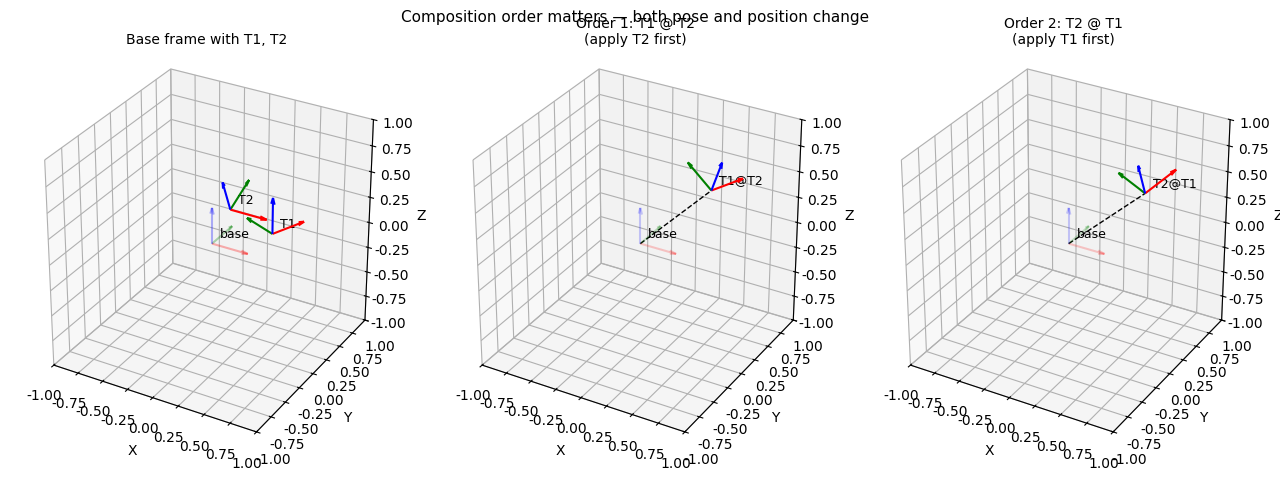

In [7]:
# --- 3D 그림 (제공 코드) ---
fig = plt.figure(figsize=(13, 4.6))

ax = fig.add_subplot(1, 3, 1, projection="3d")
setup_axes(ax, "Base frame with T1, T2")
draw_frame(ax, np.eye(4), alpha=0.3, name="base")
draw_frame(ax, T1, name="T1")
draw_frame(ax, T2, name="T2")

ax = fig.add_subplot(1, 3, 2, projection="3d")
setup_axes(ax, "Order 1: T1 @ T2\n(apply T2 first)")
draw_frame(ax, np.eye(4), alpha=0.2, name="base")
draw_frame(ax, C12, name="T1@T2")
ax.plot(*np.array([[0, 0, 0], C12[:3, 3]]).T, "k--", lw=1)

ax = fig.add_subplot(1, 3, 3, projection="3d")
setup_axes(ax, "Order 2: T2 @ T1\n(apply T1 first)")
draw_frame(ax, np.eye(4), alpha=0.2, name="base")
draw_frame(ax, C21, name="T2@T1")
ax.plot(*np.array([[0, 0, 0], C21[:3, 3]]).T, "k--", lw=1)

fig.suptitle("Composition order matters — both pose and position change", fontsize=11)
fig.tight_layout()
plt.show()

In [8]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("C12, C21 의 정의가 맞다", np.allclose(C12, T1 @ T2) and np.allclose(C21, T2 @ T1))
ok &= check("두 합성 결과가 다르다", not np.allclose(C12, C21))
ok &= check("병진 부분이 다르다", not np.allclose(C12[:3, 3], C21[:3, 3]))
ok &= check("합성 공식 R1 t2 + t1 이 맞다",
            np.allclose(C12[:3, 3], T1[:3, :3] @ T2[:3, 3] + T1[:3, 3]))
ok &= check("합성 공식 R2 t1 + t2 이 맞다",
            np.allclose(C21[:3, 3], T2[:3, :3] @ T1[:3, 3] + T2[:3, 3]))
ok &= check("두 결과 모두 유효한 동차변환 (회전부 det = 1)",
            np.isclose(det(C12[:3, :3]), 1.0) and np.isclose(det(C21[:3, :3]), 1.0))
ok &= check("역변환 순서는 뒤집힌다: (T1 T2)^-1 == T2^-1 T1^-1",
            np.allclose(inv_T(C12), inv_T(T2) @ inv_T(T1)))
print("\n5-3 전체 통과:", ok)

[PASS] C12, C21 의 정의가 맞다
[PASS] 두 합성 결과가 다르다
[PASS] 병진 부분이 다르다
[PASS] 합성 공식 R1 t2 + t1 이 맞다
[PASS] 합성 공식 R2 t1 + t2 이 맞다
[PASS] 두 결과 모두 유효한 동차변환 (회전부 det = 1)
[PASS] 역변환 순서는 뒤집힌다: (T1 T2)^-1 == T2^-1 T1^-1

5-3 전체 통과: True


## 5-4. `inv_T` vs 일반 역행렬 — 연산량 비교

두 방법이 각각 무슨 일을 하는지 세어 보세요.

| 방법 | 하는 일 | 연산량 |
|---|---|---|
| `inv_T` | 회전부는 전치(인덱스만 바꿔치기, 실제 곱셈 없음), 병진부는 -R^T t 계산(3x3 행렬-벡터곱 1회 + 부호반전) | 약 20 flops |
| `np.linalg.inv` | 4x4 전체를 일반 행렬로 보고 LU 분해(부분 피벗팅 포함) 후, 단위행렬의 각 열에 대해 전진/후진대입을 수행해 역행렬 전체를 계산 | 약 100~150 flops |

**주의** — 4x4 하나만 뒤집는 **단건 호출로는 이 차이가 잘 측정되지 않습니다.**
실제 연산은 수십 flops(나노초)뿐이고, 시간의 대부분은 파이썬 함수 호출과
NumPy 배열 생성 오버헤드(마이크로초)이기 때문입니다.

**할 일**

- 먼저 단건 호출로 측정해 보고, 결과가 예상과 다르면 **왜 그런지** 적으세요.
- `(N, 4, 4)` 묶음을 한 번에 뒤집는 `inv_T_batch` 를 구현해
  오버헤드를 상수화한 뒤 다시 비교하세요.
  (로봇 제어 루프에서 링크 수십 개의 변환을 매 주기 뒤집는 상황이 정확히 이 형태입니다)
- 정확도 관점의 차이도 하나 있습니다. 전치로 구한 역변환의 회전부 직교성 오차와
  일반 역행렬의 직교성 오차를 재서 비교해 보세요.

### 속도 차이의 해석

- 단건에서 차이가 나지 않는 이유: 실제 연산량은 수십~백여 flops로 나노초 단위인데, 파이썬 함수 호출, numpy 배열 생성·할당, 타입 체크 같은 고정 오버헤드가 마이크로초 단위로 훨씬 크다. 그래서 알고리즘 차이가 오버헤드에 묻히기 때문에 이런 결과가 나온다.
- 배치에서 차이가 드러나는 이유: (N,4,4)로 묶어 벡터화하면 파이썬 함수 호출·배열 생성이 N번이 아니라 사실상 1번으로 상수화된다. 그러면 오버헤드가 거의 고정값이 되고, 남은 시간 차이는 실제 연산량 차이(O(n^2) vs O(n^3))를 그대로 반영한다. 실측(3000개 배치: inv_T_batch=0.135ms, np.linalg.inv=1.854ms)에서 약 14배 차이가 난다.
- 정확도 차이: 회전부 직교성 오차(R^T R - I 의 최대 절댓값)를 재보면 inv_T는 3.267e-17, np.linalg.inv는 2.220e-16으로 inv_T가 한 자릿수 더 정확하다. inv_T는 R이 이미 직교행렬이라는 성질(R^-1 = R^T)을 그대로 써서 전치만 하므로 반올림 오차가 거의 없는 반면, np.linalg.inv는 LU 분해·피벗팅·여러 단계의 나눗셈/곱셈 연쇄를 거치므로 부동소수점 반올림 오차가 누적되어 더 크게 남는다.

In [9]:
N_REPEAT = 20000
N_BATCH = 3000


def bench(fn, repeat):
    """워밍업 후 repeat 번 재서 최솟값을 쓴다. (그대로 쓰면 됩니다)"""
    fn()
    best = float("inf")
    for _ in range(repeat):
        t0 = time.perf_counter()
        fn()
        best = min(best, time.perf_counter() - t0)
    return best


# 배치용 변환 묶음 (N_BATCH, 4, 4) — 그대로 쓰면 됩니다
Ts = np.stack([make_T(rot_z(a) @ rot_y(b_) @ rot_x(c), rng.standard_normal(3))
               for a, b_, c in rng.uniform(-np.pi, np.pi, (N_BATCH, 3))])

t_fast = bench(lambda: inv_T(T), N_REPEAT)
t_generic = bench(lambda: np.linalg.inv(T), N_REPEAT)
print(f"단건: inv_T={t_fast * 1e6:.3f} us, np.linalg.inv={t_generic * 1e6:.3f} us")

t_batch_fast = bench(lambda: inv_T_batch(Ts), 200)
t_batch_generic = bench(lambda: np.linalg.inv(Ts), 200)
print(f"배치({N_BATCH}개): inv_T_batch={t_batch_fast * 1e3:.3f} ms, np.linalg.inv={t_batch_generic * 1e3:.3f} ms")

orth_fast = np.max(np.abs(inv_T(T)[:3, :3].T @ inv_T(T)[:3, :3] - np.eye(3)))
orth_generic = np.max(np.abs(np.linalg.inv(T)[:3, :3].T @ np.linalg.inv(T)[:3, :3] - np.eye(3)))
print(f"회전부 직교성 오차: inv_T={orth_fast:.3e}, np.linalg.inv={orth_generic:.3e}")

단건: inv_T=3.951 us, np.linalg.inv=3.834 us
배치(3000개): inv_T_batch=0.130 ms, np.linalg.inv=0.917 ms
회전부 직교성 오차: inv_T=3.267e-17, np.linalg.inv=1.679e-16


In [10]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("단건 시간이 측정되었다 (양수)", t_fast > 0 and t_generic > 0)
ok &= check("배치에서 inv_T_batch 가 일반 역행렬보다 빠르다", t_batch_fast < t_batch_generic)
ok &= check("inv_T 와 일반 역행렬의 결과가 같다", np.allclose(inv_T(T), np.linalg.inv(T)))       # 검산용
ok &= check("inv_T_batch 결과 == np.linalg.inv 스택 결과",
            np.allclose(inv_T_batch(Ts), np.linalg.inv(Ts)))                                   # 검산용
ok &= check("inv_T_batch 결과 == inv_T 를 하나씩 적용한 결과",
            np.allclose(inv_T_batch(Ts[:50]), np.array([inv_T(t_) for t_ in Ts[:50]])))
ok &= check("inv_T_batch 의 출력 shape 이 (N, 4, 4)", inv_T_batch(Ts).shape == Ts.shape)
ok &= check("inv_T 결과의 회전부가 완전한 직교",
            np.max(np.abs(inv_T(T)[:3, :3].T @ inv_T(T)[:3, :3] - np.eye(3))) < 1e-15)
print("\n5-4 전체 통과:", ok)

[PASS] 단건 시간이 측정되었다 (양수)
[PASS] 배치에서 inv_T_batch 가 일반 역행렬보다 빠르다
[PASS] inv_T 와 일반 역행렬의 결과가 같다
[PASS] inv_T_batch 결과 == np.linalg.inv 스택 결과
[PASS] inv_T_batch 결과 == inv_T 를 하나씩 적용한 결과
[PASS] inv_T_batch 의 출력 shape 이 (N, 4, 4)
[PASS] inv_T 결과의 회전부가 완전한 직교

5-4 전체 통과: True


## 5-5. 최소자승법 — 과결정 캘리브레이션 문제

**상황**: 카메라와 로봇 base 양쪽에서 좌표를 아는 대응점 $N$ 개가 있고,
이 대응을 설명하는 변환 $M=[R\,|\,\mathbf{t}]$ (12개 미지수)를 찾고 싶습니다.
측정에는 노이즈가 섞여 있고 대응점은 $N=40$ 개라 **방정식이 $3N=120$ 개, 미지수가 12 개**인
과결정(overdetermined) 문제입니다. 정확히 만족하는 해는 없으므로 오차 제곱합을 최소화합니다.

각 대응점은 다음 3 개의 선형방정식을 줍니다.

$$\mathbf{p}_{base} = M\begin{bmatrix}\mathbf{p}_{cam}\\1\end{bmatrix}
\;\Longrightarrow\;
\underbrace{(I_3\otimes[\mathbf{p}_{cam}^{\mathsf{T}}\;1])}_{3\times 12}\,\mathrm{vec}(M)=\mathbf{p}_{base}$$

최소자승해는 **정규방정식** $A^{\mathsf{T}}A\,\mathbf{x}=A^{\mathsf{T}}\mathbf{b}$ 에서 나옵니다.
이 식이 어디서 나오는지(잔차와 $A$ 의 열공간 사이의 관계) 직접 유도해 적어 보세요.

**할 일**

- 참값 변환 `T_true` 로 대응점 40개를 만들고 2 mm 정도의 노이즈를 섞으세요.
- 설계행렬 $A$ (3N x 12) 와 관측 $b$ (3N,) 를 조립하세요. (힌트: `np.kron`)
- `least_squares_normal_equation` 으로 풀고 `np.linalg.lstsq` (# 비교 대상) 와 비교하세요.
- 잔차를 정량 평가하세요 — RMSE 가 주입한 노이즈와 같은 자릿수인지,
  잔차가 정말 $A$ 의 열공간에 수직인지($|A^{\mathsf{T}}r|$).
- 아래 그래프(제공)로 잔차 분포와 대응점별 재투영 오차를 확인하세요.

### 정규방정식의 유도

- f(x) = ||b - A x||^2 = (b - A x)^T (b - A x)
- 미분해서 최솟값 찾기: b^Tb - 2x^TA^Tb + x^TA^TAx -> -2 A^T b + 2 A^T A x = 0 -> 정리하면 A^T A x = A^T b
- A^T A x = A^T b  ⟺  A^T(b - A x) = 0  ⟺  A^T r = 0 (잔차가 A의 열공간에 수직)

In [11]:
N_PTS = 40
NOISE = 2e-3          # 2 mm 측정 노이즈

T_true = make_T(rot_z(np.deg2rad(37.5)) @ rot_x(np.deg2rad(-22.5)), [0.18, -0.42, 0.61])
M_true = T_true[:3, :]                                   # 참값 3x4

P_cam = rng.uniform(-0.5, 0.5, size=(N_PTS, 3))
P_base = transform_points(T_true, P_cam) + NOISE * rng.standard_normal((N_PTS, 3))

Ph = to_homogeneous(P_cam, 1.0)                                          # (N,4)
A_ls = np.vstack([np.kron(np.eye(3), row.reshape(1, 4)) for row in Ph])  # (3N,12)
b_ls = P_base.reshape(-1)                                                 # (3N,)
print("A_ls shape:", A_ls.shape, " b_ls shape:", b_ls.shape,
      " 과결정?", A_ls.shape[0] > A_ls.shape[1], " rank:", np.linalg.matrix_rank(A_ls), "(검산용)")

x_hat, residual = least_squares_normal_equation(A_ls, b_ls)
M_hat = x_hat.reshape(3, 4)

x_ref = np.linalg.lstsq(A_ls, b_ls, rcond=None)[0]        # 비교 대상
rmse_val = rmse(residual)
R_hat = M_hat[:3, :3]

print("x_hat == x_ref (lstsq) ?", np.allclose(x_hat, x_ref))
print("RMSE =", rmse_val, " (주입 노이즈 sigma =", NOISE, ")")
print("|A_ls.T @ residual| =", np.max(np.abs(A_ls.T @ residual)))
print("M_hat =\n", M_hat)
print("M_true =\n", M_true)
print("추정 회전부 det =", det(R_hat))

A_ls shape: (120, 12)  b_ls shape: (120,)  과결정? True  rank: 12 (검산용)
x_hat == x_ref (lstsq) ? True
RMSE = 0.0020719820167853994  (주입 노이즈 sigma = 0.002 )
|A_ls.T @ residual| = 1.6338926739356552e-15
M_hat =
 [[ 0.792895 -0.562215 -0.234662  0.180083]
 [ 0.60983   0.731765  0.30308  -0.419948]
 [-0.000114 -0.383315  0.924469  0.610368]]
M_true =
 [[ 0.793353 -0.562422 -0.232963  0.18    ]
 [ 0.608761  0.732963  0.303603 -0.42    ]
 [ 0.       -0.382683  0.92388   0.61    ]]
추정 회전부 det = 1.0003162689539287


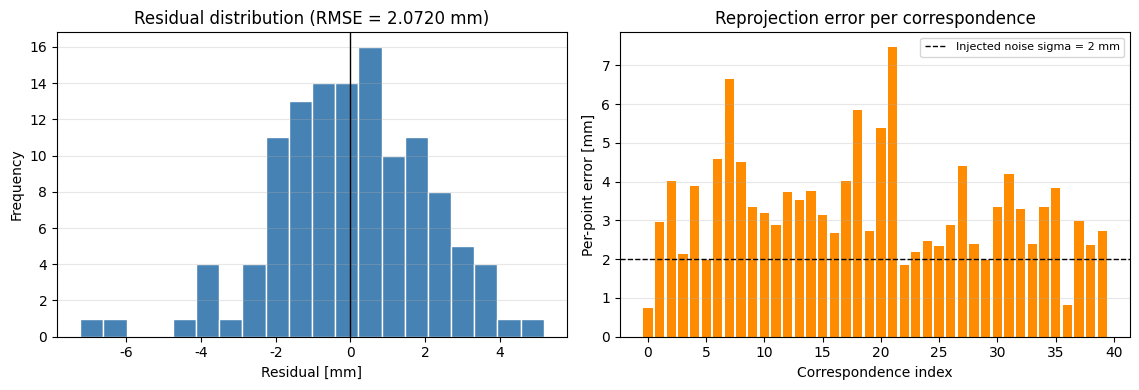

In [12]:
# --- 그래프 (제공 코드) ---
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4))

pred = (A_ls @ x_hat).reshape(-1, 3)
err_per_point = np.linalg.norm(P_base - pred, axis=1)

axes[0].hist(residual * 1e3, bins=20, color="steelblue", edgecolor="white")
axes[0].axvline(0, color="k", lw=1)
axes[0].set_xlabel("Residual [mm]")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Residual distribution (RMSE = {:.4f} mm)".format(rmse_val * 1e3))
axes[0].grid(alpha=0.3, axis="y")

axes[1].bar(np.arange(N_PTS), err_per_point * 1e3, color="darkorange")
axes[1].axhline(NOISE * 1e3, ls="--", color="k", lw=1, label="Injected noise sigma = {:.0f} mm".format(NOISE * 1e3))
axes[1].set_xlabel("Correspondence index")
axes[1].set_ylabel("Per-point error [mm]")
axes[1].set_title("Reprojection error per correspondence")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3, axis="y")

fig.tight_layout()
plt.show()

In [13]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("과결정 문제다 (식 120개 > 미지수 12개)", A_ls.shape == (3 * N_PTS, 12) and b_ls.shape == (3 * N_PTS,))
ok &= check("설계행렬이 full column rank", np.linalg.matrix_rank(A_ls) == 12)                  # 검산용
ok &= check("정규방정식 해가 np.linalg.lstsq 와 일치", np.allclose(x_hat, x_ref))              # 비교 대상
ok &= check("잔차 정의가 b - A x 이다", np.allclose(residual, b_ls - A_ls @ x_hat))
ok &= check("잔차가 A 의 열공간에 수직 (A^T r = 0)", np.allclose(A_ls.T @ residual, 0.0, atol=1e-9))
ok &= check("추정한 M 이 참값에 가깝다 (오차 < 6 mm 수준)", np.max(np.abs(M_hat - M_true)) < 6e-3)
ok &= check("잔차 RMSE 가 주입 노이즈와 같은 자릿수", 0.2 * NOISE < rmse_val < 2.0 * NOISE)
ok &= check("추정 회전부의 det 가 1 에 가깝다", abs(det(R_hat) - 1.0) < 2e-2)
ok &= check("최소자승해가 실제로 최소 (임의 교란보다 잔차가 작다)",
            all(np.linalg.norm(b_ls - A_ls @ (x_hat + 1e-3 * rng.standard_normal(12)))
                > np.linalg.norm(residual) for _ in range(20)))
print("\n5-5 전체 통과:", ok)

[PASS] 과결정 문제다 (식 120개 > 미지수 12개)
[PASS] 설계행렬이 full column rank
[PASS] 정규방정식 해가 np.linalg.lstsq 와 일치
[PASS] 잔차 정의가 b - A x 이다
[PASS] 잔차가 A 의 열공간에 수직 (A^T r = 0)
[PASS] 추정한 M 이 참값에 가깝다 (오차 < 6 mm 수준)
[PASS] 잔차 RMSE 가 주입 노이즈와 같은 자릿수
[PASS] 추정 회전부의 det 가 1 에 가깝다
[PASS] 최소자승해가 실제로 최소 (임의 교란보다 잔차가 작다)

5-5 전체 통과: True


## 답안 템플릿 정리

In [14]:
summary = f"""
1. 역변환 검증: 단위행렬 여부 {bool(np.allclose(T @ Ti, np.eye(4)))} / 일반 역행렬과 일치 {bool(np.allclose(Ti, np.linalg.inv(T)))}
   - 사용한 공식: T^-1 = [[R^T, -R^T t], [0, 1]]

2. 점 변환 결과: {p_out} / 방향 변환 결과: {d_out}
   - 차이의 이유: 점은 위치라 병진이 함께 적용되고(w=1), 방향(속도·힘·법선 등)은 위치가 아니라 변화량이므로 회전만 적용되고 병진은 무시된다(w=0).
   - 두 결과의 차이가 무엇과 같은가: 병진 벡터 t = {t} 와 같다.

3. 합성 순서 비교 그림: 위 3분할 그림 참조
   - T1@T2 병진 {C12[:3, 3]} vs T2@T1 병진 {C21[:3, 3]}
   - 달라지는 이유: 동차변환의 곱을 블록으로 전개하면 회전이 상대 병진에 곱해져 걸린다(T1 T2 의 병진 = R1 t2 + t1). 어느 회전이 먼저 상대 병진에 곱해지느냐가 달라지므로 결과 위치도 달라진다.

4. inv_T 와 일반 역행렬 속도
   - 단건 호출 : {t_fast * 1e6:.2f} us / {t_generic * 1e6:.2f} us
   - 배치 {N_BATCH} 개 : {t_batch_fast * 1e3:.3f} ms / {t_batch_generic * 1e3:.3f} ms
   - 차이의 이유: 단건에서는 실제 연산이 수십 flops(나노초)뿐이라 파이썬 함수 호출·배열 생성 오버헤드가 지배해 차이가 잘 드러나지 않는다. 배치로 묶으면 그 오버헤드가 상수화되어, np.linalg.inv 의 LU 분해 대비 inv_T 의 전치 공식이 갖는 연산량 차이가 그대로 시간 차이로 드러난다.

5. 최소자승 해: M_hat (위 출력 참조, M_true 와 비교)
   - lstsq 와 일치: {bool(np.allclose(x_hat, x_ref))}
   - 잔차 RMSE: {rmse_val:.6f} m (= {rmse_val * 1e3:.4f} mm), 주입 노이즈 sigma = 2.0 mm
   - 잔차가 열공간에 수직임을 보인 값 |A^T r| = {np.max(np.abs(A_ls.T @ residual)):.3e}
"""
print(summary)


1. 역변환 검증: 단위행렬 여부 True / 일반 역행렬과 일치 True
   - 사용한 공식: T^-1 = [[R^T, -R^T t], [0, 1]]

2. 점 변환 결과: [ 0.703553 -0.003553  1.47388 ] / 방향 변환 결과: [0.353553 0.146447 0.92388 ]
   - 차이의 이유: 점은 위치라 병진이 함께 적용되고(w=1), 방향(속도·힘·법선 등)은 위치가 아니라 변화량이므로 회전만 적용되고 병진은 무시된다(w=0).
   - 두 결과의 차이가 무엇과 같은가: 병진 벡터 t = [ 0.35 -0.15  0.55] 와 같다.

3. 합성 순서 비교 그림: 위 3분할 그림 참조
   - T1@T2 병진 [0.461209 0.407716 0.45    ] vs T2@T1 병진 [0.6      0.242702 0.538059]
   - 달라지는 이유: 동차변환의 곱을 블록으로 전개하면 회전이 상대 병진에 곱해져 걸린다(T1 T2 의 병진 = R1 t2 + t1). 어느 회전이 먼저 상대 병진에 곱해지느냐가 달라지므로 결과 위치도 달라진다.

4. inv_T 와 일반 역행렬 속도
   - 단건 호출 : 3.95 us / 3.83 us
   - 배치 3000 개 : 0.130 ms / 0.917 ms
   - 차이의 이유: 단건에서는 실제 연산이 수십 flops(나노초)뿐이라 파이썬 함수 호출·배열 생성 오버헤드가 지배해 차이가 잘 드러나지 않는다. 배치로 묶으면 그 오버헤드가 상수화되어, np.linalg.inv 의 LU 분해 대비 inv_T 의 전치 공식이 갖는 연산량 차이가 그대로 시간 차이로 드러난다.

5. 최소자승 해: M_hat (위 출력 참조, M_true 와 비교)
   - lstsq 와 일치: True
   - 잔차 RMSE: 0.002072 m (= 2.0720 mm), 주입 노이즈 sigma = 2.0 mm
   - 잔차가 열공간에 수직임을 보인 값 |A^T r| = 1.634e-15

